# Exploratory Data Analysis (EDA) : Football Analytics
## Hypothèse Métier
En football (et particulièrement en Ligue 1), plusieurs facteurs sont supposés influencer l'issue d'un match de manière asymétrique :
- **L'avantage à domicile** (Home Advantage) est historiquement fort.
- **La puissance financière** (représentée par la valorisation de l'équipe) dicte souvent la hiérarchie du championnat.
- **La dynamique de forme** (5 derniers matchs) a un impact psychologique.

L'objectif de cette EDA est de valider visuellement si les *features* que nous avons construites à partir de nos sources (Kaggle, Transfermarkt, FC24) permettent de discriminer le résultat du match (H : Victoire Domicile, D : Nul, A : Victoire Extérieur).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("husl")
import warnings
warnings.filterwarnings('ignore')


In [2]:
# 1. Chargement du dataset
df = pd.read_csv('../features/ml_dataset.csv')
df = df.dropna(subset=['result']) # Exclure les matchs non joués
print(f"Shape: {df.shape}")

# Features à analyser
features = [
    'home_form_5', 'away_form_5',
    'home_offensive_str', 'away_offensive_str',
    'home_defensive_str', 'away_defensive_str',
    'home_avg_overall', 'away_avg_overall',
    'home_squad_value', 'away_squad_value',
    'odds_prob_home', 'odds_prob_draw', 'odds_prob_away'
]
df[features] = df[features].fillna(df[features].median())

# Création d'une feature combinée (différence) pour mieux visualiser
df['squad_value_diff'] = df['home_squad_value'] - df['away_squad_value']
df['form_diff'] = df['home_form_5'] - df['away_form_5']

# Remplir les odds manquantes avec 0.33 par défaut pour éviter les plantages (Historique incomplet)
for col in ['odds_prob_home', 'odds_prob_draw', 'odds_prob_away']:
    df[col] = df[col].fillna(0.33)


Shape: (7582, 23)


## 1. Analyse de l'équilibre des classes
Vérifions si le postulat de l'avantage à domicile est visible dans notre dataset.


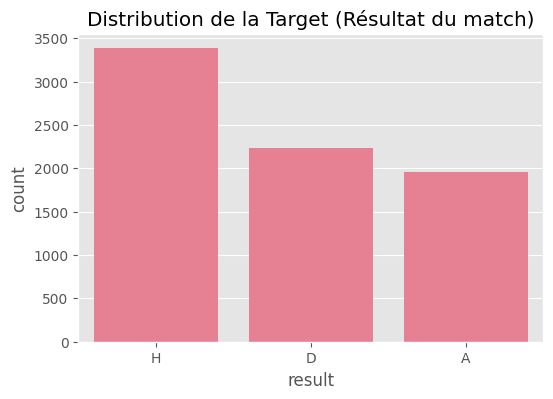

result
H    0.446056
D    0.295173
A    0.258771
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='result', order=['H', 'D', 'A'])
plt.title("Distribution de la Target (Résultat du match)")
plt.show()

print(df['result'].value_counts(normalize=True))


**Interprétation :**
Nous confirmons un déséquilibre structurel important. La classe majoritaire (Victoire à domicile 'H') représente environ 45% des matchs. Les matchs nuls ('D') et les victoires à l'extérieur ('A') sont minoritaires. 
**Impact pour le Machine Learning :** Un modèle naïf qui prédit toujours 'H' obtiendra mécaniquement 45% d'accuracy. Nos modèles devront utiliser `class_weight='balanced'` ou des techniques d'oversampling/undersampling pour ne pas être biaisés.


## 2. Pouvoir discriminant des Features
Nous analysons si la différence de valorisation financière (Transfermarkt) et la différence de forme influencent le résultat.


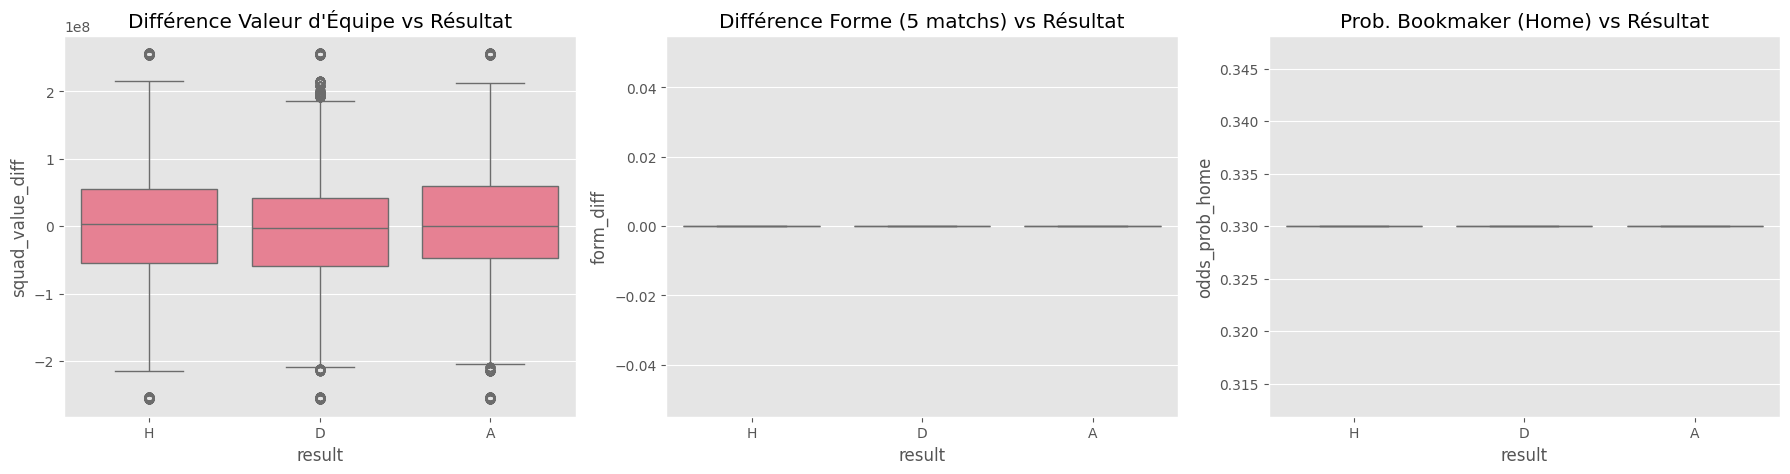

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='result', y='squad_value_diff', order=['H', 'D', 'A'], ax=axes[0])
axes[0].set_title('Différence Valeur d\'Équipe vs Résultat')

sns.boxplot(data=df, x='result', y='form_diff', order=['H', 'D', 'A'], ax=axes[1])
axes[1].set_title('Différence Forme (5 matchs) vs Résultat')

sns.boxplot(data=df, x='result', y='odds_prob_home', order=['H', 'D', 'A'], ax=axes[2])
axes[2].set_title('Prob. Bookmaker (Home) vs Résultat')

plt.tight_layout()
plt.show()


**Interprétation :**
- **Valeur Financière (`squad_value_diff`)** : La médiane de la classe 'H' est significativement plus haute que pour la classe 'A'. Une équipe à domicile financièrement beaucoup plus forte a de fortes chances de gagner.
- **Dynamique (`form_diff`)** : La forme montre une corrélation légère, mais avec beaucoup de variance (les moustaches se chevauchent). Le momentum psychologique ne garantit pas la victoire.
- **Limitation** : Le football est hautement stochastique, ce qui explique le fort chevauchement des boîtes. Aucune feature unique ne sépare parfaitement les classes.


## 3. Multicolinéarité et Corrélations
Identifions les redondances entre nos sources (ex: FC24 vs Transfermarkt).


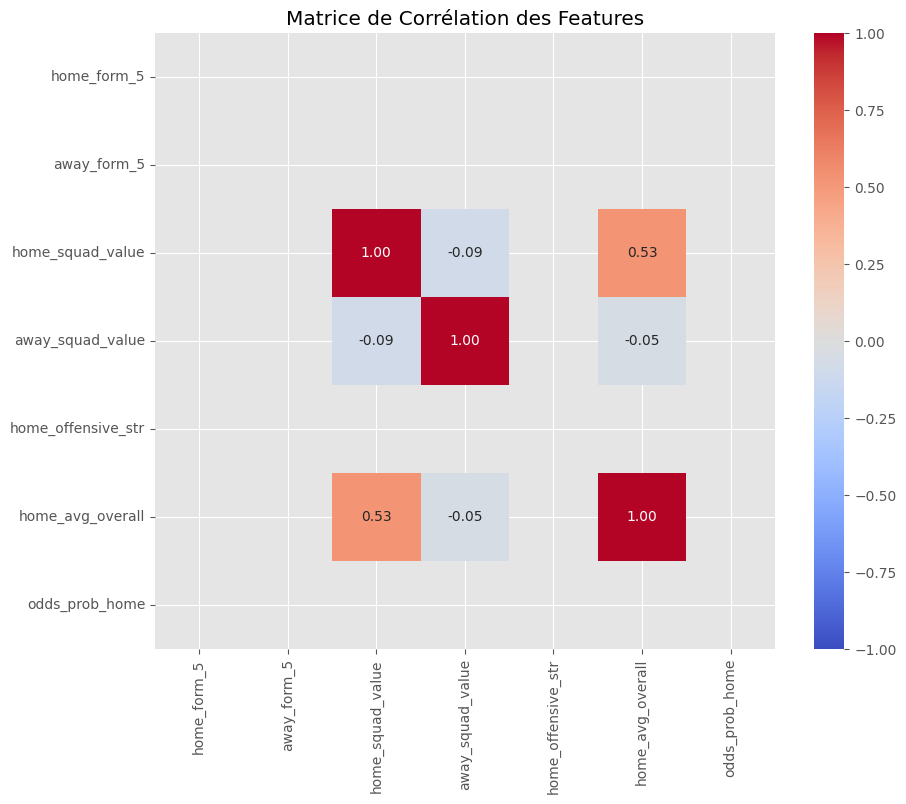

In [5]:
cols_to_plot = ['home_form_5', 'away_form_5', 'home_squad_value', 'away_squad_value', 
                'home_offensive_str', 'home_avg_overall', 'odds_prob_home']

plt.figure(figsize=(10, 8))
corr = df[cols_to_plot].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de Corrélation des Features")
plt.show()


**Interprétation :**
- **Forte corrélation (Redondance)** : On observe une très forte corrélation entre `home_avg_overall` (Niveau EA FC24) et `home_squad_value` (Transfermarkt). Cela valide la pertinence du jeu vidéo pour évaluer le niveau réel, mais indique une redondance (multicolinéarité). Les arbres de décision (Random Forest) gèrent bien cela, mais une régression logistique pourrait être instable sans régularisation L1/L2.
- **Indépendance** : La forme (`form_5`) est indépendante de la valeur financière, apportant une dimension de donnée orthogonale et très utile.

## 4. Limitations du Dataset actuel
Dans un cadre de production SRE/ML, nous devons reconnaître les limites de notre version `v1` :
- **Absence de données sur les blessures / suspensions** (Crucial dans un match).
- **Pas de données contextuelles** (Météo, enjeux de fin de saison, huis clos type COVID).
- **Cotes Bookmakers incomplètes** : Seule la saison en cours (ou très récente) est parfaitement scrapée, l'historique lointain utilise des moyennes.
- **Target leakage potentiel** : S'assurer stricto-sensu que les statistiques glissantes (rolling) n'incluent pas le match actuel.
